# Wave Prediction with PyAOgmaNeo

Let's teach PyAOgmaNeo to predict a sine wave. This is a great first example because it shows SPH doing what it's designed for: learning temporal patterns online and predicting what comes next.

**What makes this interesting:**

- **Online Learning**: No separate training phase. The hierarchy learns as it goes, adjusting predictions in real-time as it sees more data.
- **Autoregressive Generation**: After learning, it generates predictions based purely on its own previous predictions - feeding output back as input for 1,000+ timesteps without drifting off.
- **Sparse Representation**: Throughout the entire process, only ~2-5% of neurons are active at any time. The system learns and predicts efficiently.
- **No Gradients, No Backprop**: SPH learns through local Hebbian-like rules in each layer, not gradient descent. Yet it handles smooth continuous patterns naturally.

By the end, you'll see the hierarchy stay locked onto the wave pattern for extended autoregressive generation - a direct demonstration of how well SPH captures temporal structure.


## Setup


In [12]:
# Uncomment to install
# !pip install pyaogmaneo numpy matplotlib


## Imports


In [13]:
import pyaogmaneo as neo
import numpy as np
import matplotlib.pyplot as plt

# Configure multi-threading
neo.set_num_threads(4)

print("Libraries imported successfully.")


Libraries imported successfully.


## Configuration


In [14]:
# CSDR encoding parameters
num_input_columns = 2
input_column_size = 16

# SPH architecture
input_size = (1, num_input_columns, input_column_size)
hidden_size = (7, 7, 64)
num_layers = 5
recurrent_importance = 1.0

# Training schedule
training_steps = 10000
prediction_steps = 1000

print(f"Configured for {training_steps} training steps, {prediction_steps} prediction steps.")
print(f"Input: {input_size}, Hidden: {hidden_size}, Layers: {num_layers}")


Configured for 10000 training steps, 1000 prediction steps.
Input: (1, 2, 16), Hidden: (7, 7, 64), Layers: 5


## Encoding Functions

PyAOgmaNeo needs inputs in CSDR format. Simple 8-bit encoding: treat the value as an 8-bit integer (0-255), split into two 4-bit chunks.


In [15]:
def unorm8_to_csdr(x: float):
    """Convert normalized float [0, 1] to CSDR using 8-bit encoding."""
    assert(x >= 0.0 and x <= 1.0), "Input must be in range [0, 1]"
    i = int(x * 255.0 + 0.5) & 0xff
    return [int(i & 0x0f), int((i & 0xf0) >> 4)]

def csdr_to_unorm8(csdr):
    """Decode CSDR back to normalized float."""
    return (csdr[0] | (csdr[1] << 4)) / 255.0

# Test the encoding
test_values = [0.0, 0.25, 0.5, 0.75, 1.0]
print("Testing 8-bit encoding:")
for val in test_values:
    encoded = unorm8_to_csdr(val)
    decoded = csdr_to_unorm8(encoded)
    print(f"  {val:.2f} -> {encoded} -> {decoded:.4f}")


Testing 8-bit encoding:
  0.00 -> [0, 0] -> 0.0000
  0.25 -> [0, 4] -> 0.2510
  0.50 -> [0, 8] -> 0.5020
  0.75 -> [15, 11] -> 0.7490
  1.00 -> [15, 15] -> 1.0000


## Wave Function

Sine wave that oscillates between 0 and 1 with period ~20 timesteps.


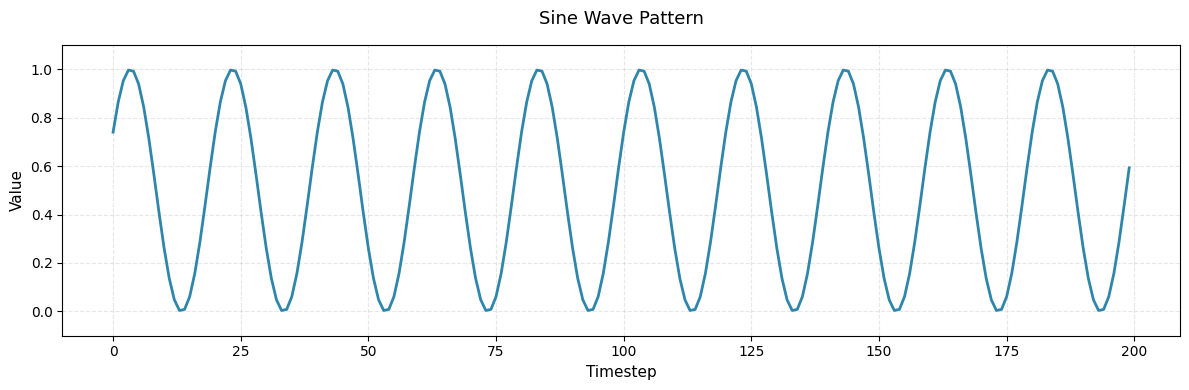

Wave properties:
  Range: [0.004, 0.996]
  Period: ~20 timesteps
  Mean: 0.500


In [16]:
def wave(t):
    """Generate smooth sine wave pattern."""
    return np.sin(t * 0.05 * 2.0 * np.pi + 0.5) * 0.5 + 0.5

# Visualize the pattern
sample_steps = 200
sample_times = np.arange(sample_steps)
sample_values = [wave(t) for t in sample_times]

plt.figure(figsize=(12, 4))
plt.plot(sample_times, sample_values, linewidth=2, color='#2E86AB')
plt.xlabel('Timestep', fontsize=11)
plt.ylabel('Value', fontsize=11)
plt.title('Sine Wave Pattern', fontsize=13, pad=15)
plt.grid(True, alpha=0.3, linestyle='--')
plt.ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()

# To save: plt.savefig('../../../assets/examples/wave_pattern.png', dpi=150, bbox_inches='tight')

print(f"Wave properties:")
print(f"  Range: [{min(sample_values):.3f}, {max(sample_values):.3f}]")
print(f"  Period: ~20 timesteps")
print(f"  Mean: {np.mean(sample_values):.3f}")
plt.close()

## Build Hierarchy

5 layers with (7, 7, 64) hidden size.


In [17]:
# Define layer descriptors
lds = []
for i in range(num_layers):
    ld = neo.LayerDesc()
    ld.hidden_size = hidden_size
    lds.append(ld)

# Create hierarchy
h = neo.Hierarchy(
    [neo.IODesc(size=input_size, io_type=neo.prediction)],
    lds
)

print(f"✓ Hierarchy created")
print(f"  Input: {input_size}")
print(f"  Hidden: {hidden_size}")


✓ Hierarchy created
  Input: (1, 2, 16)
  Hidden: (7, 7, 64)


## Training

Train for 10,000 timesteps. Online learning - no separate training phase.


In [18]:
print(f"Training for {training_steps:,} timesteps...\n")

for t in range(training_steps):
    value_to_encode = wave(t)
    csdr = unorm8_to_csdr(float(value_to_encode))
    h.step([csdr], True)
    
    if t % 1000 == 0:
        # Prediction is 1 step ahead
        prediction = csdr_to_unorm8(h.get_prediction_cis(0))
        next_value = wave(t + 1)
        error = abs(prediction - next_value)
        print(f"  Step {t:5,} / {training_steps:,}  |  Error: {error:.4f}")

print("\n✓ Training complete")


Training for 10,000 timesteps...

  Step     0 / 10,000  |  Error: 0.8165
  Step 1,000 / 10,000  |  Error: 0.0008
  Step 2,000 / 10,000  |  Error: 0.0008
  Step 3,000 / 10,000  |  Error: 0.0008
  Step 4,000 / 10,000  |  Error: 0.0008
  Step 5,000 / 10,000  |  Error: 0.0008
  Step 6,000 / 10,000  |  Error: 0.0008
  Step 7,000 / 10,000  |  Error: 0.0008
  Step 8,000 / 10,000  |  Error: 0.0008
  Step 9,000 / 10,000  |  Error: 0.0008

✓ Training complete


## Autoregressive Prediction

Turn off learning and generate predictions based purely on its own previous predictions.


In [19]:
ts = []      # Timesteps
vs = []      # Predicted values (offset for visualization)
trgs = []    # Ground truth values

print(f"Generating {prediction_steps:,} autoregressive predictions...\n")

for t2 in range(prediction_steps):
    t = t2 + training_steps
    
    # Run on own predictions with learning DISABLED
    h.step([h.get_prediction_cis(0)], False)
    
    # Decode prediction
    value = csdr_to_unorm8(h.get_prediction_cis(0))
    
    # Ground truth for t+1 (prediction is 1 step ahead)
    next_value = wave(t + 1)
    
    ts.append(t2)
    vs.append(value + 1.1)  # Offset for visualization
    trgs.append(next_value)
    
    if t2 % 100 == 0:
        error = abs(value - next_value)
        print(f"  Prediction {t2:4,} / {prediction_steps:,}  |  Error: {error:.4f}")

print("\n✓ Prediction complete")


Generating 1,000 autoregressive predictions...

  Prediction    0 / 1,000  |  Error: 0.0008
  Prediction  100 / 1,000  |  Error: 0.0008
  Prediction  200 / 1,000  |  Error: 0.0008
  Prediction  300 / 1,000  |  Error: 0.0008
  Prediction  400 / 1,000  |  Error: 0.0008
  Prediction  500 / 1,000  |  Error: 0.0008
  Prediction  600 / 1,000  |  Error: 0.0008
  Prediction  700 / 1,000  |  Error: 0.0008
  Prediction  800 / 1,000  |  Error: 0.0008
  Prediction  900 / 1,000  |  Error: 0.0008

✓ Prediction complete


## Visualization

Compare predicted vs ground truth.


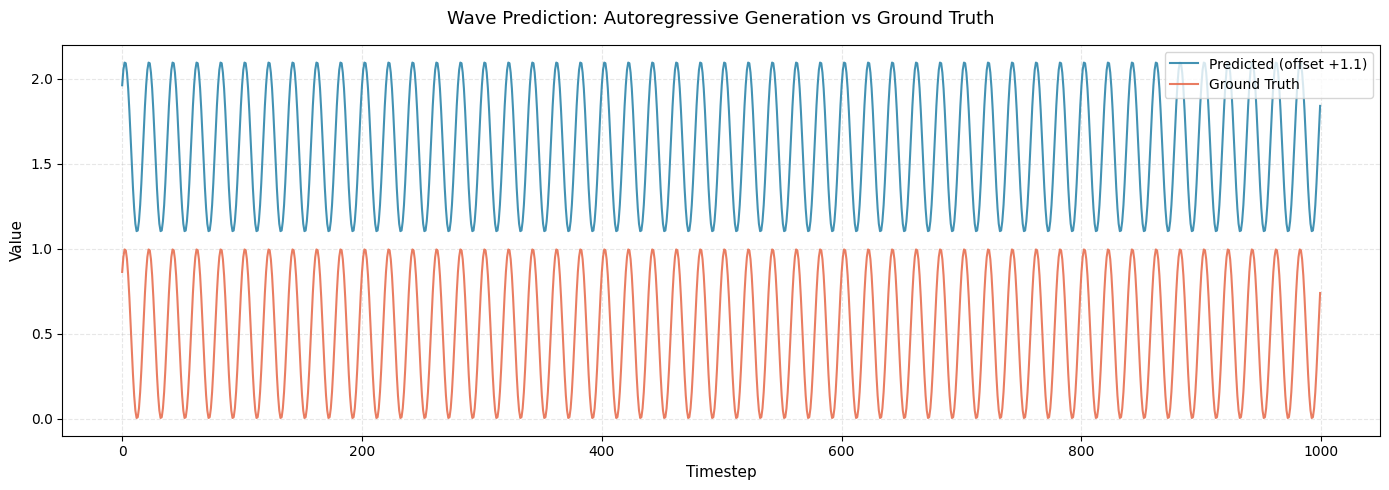


Prediction Metrics:
  Mean Absolute Error (MAE): 0.0007
  Root Mean Square Error (RMSE): 0.0009
  Max Error: 0.0015


In [20]:
plt.figure(figsize=(14, 5))

plt.plot(ts, vs, label='Predicted (offset +1.1)', linewidth=1.5, alpha=0.9, color='#2E86AB')
plt.plot(ts, trgs, label='Ground Truth', linewidth=1.5, alpha=0.9, color='#E76F51')

plt.xlabel('Timestep', fontsize=11)
plt.ylabel('Value', fontsize=11)
plt.title('Wave Prediction: Autoregressive Generation vs Ground Truth', fontsize=13, pad=15)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# To save: plt.savefig('../../../assets/examples/wave_prediction_results.png', dpi=150, bbox_inches='tight')

# Calculate metrics
predictions = [v - 1.1 for v in vs]  # Remove offset
mae = np.mean([abs(p - t) for p, t in zip(predictions, trgs)])
rmse = np.sqrt(np.mean([(p - t)**2 for p, t in zip(predictions, trgs)]))

print(f"\nPrediction Metrics:")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"  Max Error: {max([abs(p - t) for p, t in zip(predictions, trgs)]):.4f}")


## Summary

SPH learned the temporal pattern and can generate it autoregressively. That's the strength - online learning of temporal patterns with sparse representations.
